<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 1, Forecasting Moderno**

Importamos lo necesario

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### **A) Forecasting point-based vs probabilístico**

Generamos una serie temporal

In [ ]:
np.random.seed(42)

t = np.arange(200)
y = 0.5 * t + 10 * np.sin(t / 10) + np.random.normal(0, 5, size=len(t))

In [ ]:
print(t)
print("_"*20)
print(y)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199]
____________________
[  2.48357077   0.80701266   6.225136    12.07035135   4.72341655
   6.1235706   16.54248881  13.77935052   8.82618898  15.04606931
  11.09762138  12.08342483  16.530

Creamos dataset supervisado

In [ ]:
X = t.reshape(-1, 1)
print(X)

[[  0]
 [  1]
 [  2]
 [  3]
 [  4]
 [  5]
 [  6]
 [  7]
 [  8]
 [  9]
 [ 10]
 [ 11]
 [ 12]
 [ 13]
 [ 14]
 [ 15]
 [ 16]
 [ 17]
 [ 18]
 [ 19]
 [ 20]
 [ 21]
 [ 22]
 [ 23]
 [ 24]
 [ 25]
 [ 26]
 [ 27]
 [ 28]
 [ 29]
 [ 30]
 [ 31]
 [ 32]
 [ 33]
 [ 34]
 [ 35]
 [ 36]
 [ 37]
 [ 38]
 [ 39]
 [ 40]
 [ 41]
 [ 42]
 [ 43]
 [ 44]
 [ 45]
 [ 46]
 [ 47]
 [ 48]
 [ 49]
 [ 50]
 [ 51]
 [ 52]
 [ 53]
 [ 54]
 [ 55]
 [ 56]
 [ 57]
 [ 58]
 [ 59]
 [ 60]
 [ 61]
 [ 62]
 [ 63]
 [ 64]
 [ 65]
 [ 66]
 [ 67]
 [ 68]
 [ 69]
 [ 70]
 [ 71]
 [ 72]
 [ 73]
 [ 74]
 [ 75]
 [ 76]
 [ 77]
 [ 78]
 [ 79]
 [ 80]
 [ 81]
 [ 82]
 [ 83]
 [ 84]
 [ 85]
 [ 86]
 [ 87]
 [ 88]
 [ 89]
 [ 90]
 [ 91]
 [ 92]
 [ 93]
 [ 94]
 [ 95]
 [ 96]
 [ 97]
 [ 98]
 [ 99]
 [100]
 [101]
 [102]
 [103]
 [104]
 [105]
 [106]
 [107]
 [108]
 [109]
 [110]
 [111]
 [112]
 [113]
 [114]
 [115]
 [116]
 [117]
 [118]
 [119]
 [120]
 [121]
 [122]
 [123]
 [124]
 [125]
 [126]
 [127]
 [128]
 [129]
 [130]
 [131]
 [132]
 [133]
 [134]
 [135]
 [136]
 [137]
 [138]
 [139]
 [140]
 [141]
 [142]

Realizamos holdout

In [ ]:
train_size = 150

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

In [ ]:
print(X_train)
print("_"*20)
print(y_train)

[[  0]
 [  1]
 [  2]
 [  3]
 [  4]
 [  5]
 [  6]
 [  7]
 [  8]
 [  9]
 [ 10]
 [ 11]
 [ 12]
 [ 13]
 [ 14]
 [ 15]
 [ 16]
 [ 17]
 [ 18]
 [ 19]
 [ 20]
 [ 21]
 [ 22]
 [ 23]
 [ 24]
 [ 25]
 [ 26]
 [ 27]
 [ 28]
 [ 29]
 [ 30]
 [ 31]
 [ 32]
 [ 33]
 [ 34]
 [ 35]
 [ 36]
 [ 37]
 [ 38]
 [ 39]
 [ 40]
 [ 41]
 [ 42]
 [ 43]
 [ 44]
 [ 45]
 [ 46]
 [ 47]
 [ 48]
 [ 49]
 [ 50]
 [ 51]
 [ 52]
 [ 53]
 [ 54]
 [ 55]
 [ 56]
 [ 57]
 [ 58]
 [ 59]
 [ 60]
 [ 61]
 [ 62]
 [ 63]
 [ 64]
 [ 65]
 [ 66]
 [ 67]
 [ 68]
 [ 69]
 [ 70]
 [ 71]
 [ 72]
 [ 73]
 [ 74]
 [ 75]
 [ 76]
 [ 77]
 [ 78]
 [ 79]
 [ 80]
 [ 81]
 [ 82]
 [ 83]
 [ 84]
 [ 85]
 [ 86]
 [ 87]
 [ 88]
 [ 89]
 [ 90]
 [ 91]
 [ 92]
 [ 93]
 [ 94]
 [ 95]
 [ 96]
 [ 97]
 [ 98]
 [ 99]
 [100]
 [101]
 [102]
 [103]
 [104]
 [105]
 [106]
 [107]
 [108]
 [109]
 [110]
 [111]
 [112]
 [113]
 [114]
 [115]
 [116]
 [117]
 [118]
 [119]
 [120]
 [121]
 [122]
 [123]
 [124]
 [125]
 [126]
 [127]
 [128]
 [129]
 [130]
 [131]
 [132]
 [133]
 [134]
 [135]
 [136]
 [137]
 [138]
 [139]
 [140]
 [141]
 [142]

### **A.1) Point-based Forecasting**

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

point_forecast = model.predict(X_test)

In [ ]:
print(point_forecast)

[ 75.72562781  76.22545286  76.72527791  77.22510295  77.724928
  78.22475304  78.72457809  79.22440313  79.72422818  80.22405322
  80.72387827  81.22370331  81.72352836  82.2233534   82.72317845
  83.22300349  83.72282854  84.22265358  84.72247863  85.22230367
  85.72212872  86.22195376  86.72177881  87.22160385  87.7214289
  88.22125394  88.72107899  89.22090403  89.72072908  90.22055412
  90.72037917  91.22020421  91.72002926  92.2198543   92.71967935
  93.21950439  93.71932944  94.21915448  94.71897953  95.21880457
  95.71862962  96.21845466  96.71827971  97.21810475  97.7179298
  98.21775484  98.71757989  99.21740493  99.71722998 100.21705502]


### **A.2) Probabilistic Forecasting**

Estimamos la desviación estándar de los residuos

In [ ]:
train_pred = model.predict(X_train)
residuals = y_train - train_pred

sigma = np.std(residuals)

Definimos intervalo de predicción 95%

Esto convierte cada predicción puntual en una banda del 95%, restándole y sumándole 1. Convierte cada predicción puntual en una banda del 95%, restándole y sumándole 1.96·σ para obtener el piso (lower) y el techo (upper) del intervalo de predicción.

In [ ]:
lower = point_forecast - 1.96 * sigma
upper = point_forecast + 1.96 * sigma

In [ ]:
print(lower)
print(upper)

[59.47077173 59.97059678 60.47042182 60.97024687 61.47007191 61.96989696
 62.469722   62.96954705 63.46937209 63.96919714 64.46902218 64.96884723
 65.46867227 65.96849732 66.46832236 66.96814741 67.46797245 67.9677975
 68.46762254 68.96744759 69.46727263 69.96709768 70.46692272 70.96674777
 71.46657281 71.96639786 72.4662229  72.96604795 73.46587299 73.96569804
 74.46552308 74.96534813 75.46517317 75.96499822 76.46482326 76.96464831
 77.46447335 77.9642984  78.46412344 78.96394849 79.46377353 79.96359858
 80.46342362 80.96324867 81.46307371 81.96289876 82.4627238  82.96254885
 83.46237389 83.96219894]
[ 91.9804839   92.48030894  92.98013399  93.47995903  93.97978408
  94.47960912  94.97943417  95.47925922  95.97908426  96.47890931
  96.97873435  97.4785594   97.97838444  98.47820949  98.97803453
  99.47785958  99.97768462 100.47750967 100.97733471 101.47715976
 101.9769848  102.47680985 102.97663489 103.47645994 103.97628498
 104.47611003 104.97593507 105.47576012 105.97558516 106.4754

Visualizamos

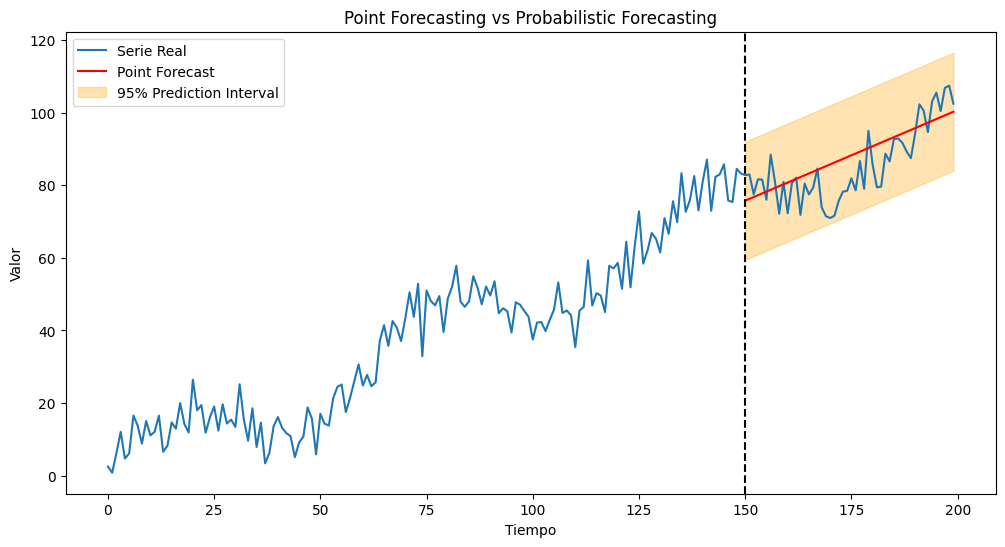

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(t, y, label='Serie Real')

plt.plot(
    X_test.flatten(),
    point_forecast,
    color='red',
    label='Point Forecast'
)

plt.fill_between(
    X_test.flatten(),
    lower,
    upper,
    color='orange',
    alpha=0.3,
    label='95% Prediction Interval'
)

plt.axvline(train_size, color='black', linestyle='--')

plt.legend()
plt.title('Point Forecasting vs Probabilistic Forecasting')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.show()

----

### **B) Forecasting Global vs Local**

Generamos tres series temporales

In [ ]:
np.random.seed(42)

In [ ]:
t = np.arange(100)

In [ ]:
serie_A = 0.5*t + 10*np.sin(t/10) + np.random.normal(0, 3, len(t))
serie_B = 0.8*t + 15*np.sin(t/15) + np.random.normal(0, 3, len(t))
serie_C = 0.3*t + 5*np.sin(t/8) + np.random.normal(0, 3, len(t))

Realizamos holdout

In [ ]:
train_size = 80

train_x = t[:train_size].reshape(-1,1)
train_y = serie_A[:train_size]

test_x = t[train_size:].reshape(-1,1)
test_y = serie_A[train_size:]

### **B.1) Local Forecasting**

In [ ]:
local_model_A = LinearRegression()
local_model_A.fit(train_x, train_y)

LinearRegression()

Realizamos la predicción

In [ ]:
pred_local_A = local_model_A.predict(test_x)

### **B.2) Global Forecasting**

Se realizará un solo modelo para todas las series

In [ ]:
X_global = []
y_global = []

for serie_id, serie in enumerate([serie_A, serie_B, serie_C]):

    for i in range(train_size):

        X_global.append([
            t[i],
            serie_id
        ])

        y_global.append(serie[i])

X_global = np.array(X_global)
y_global = np.array(y_global)

global_model = LinearRegression()
global_model.fit(X_global, y_global)

Realizamos predicción para la serie A usando el modelo global

In [ ]:
X_future = np.column_stack([
    t[train_size:],
    np.zeros(len(t[train_size:]))  # id de Serie A
])

In [ ]:
pred_global_A = global_model.predict(X_future)

Graficamos

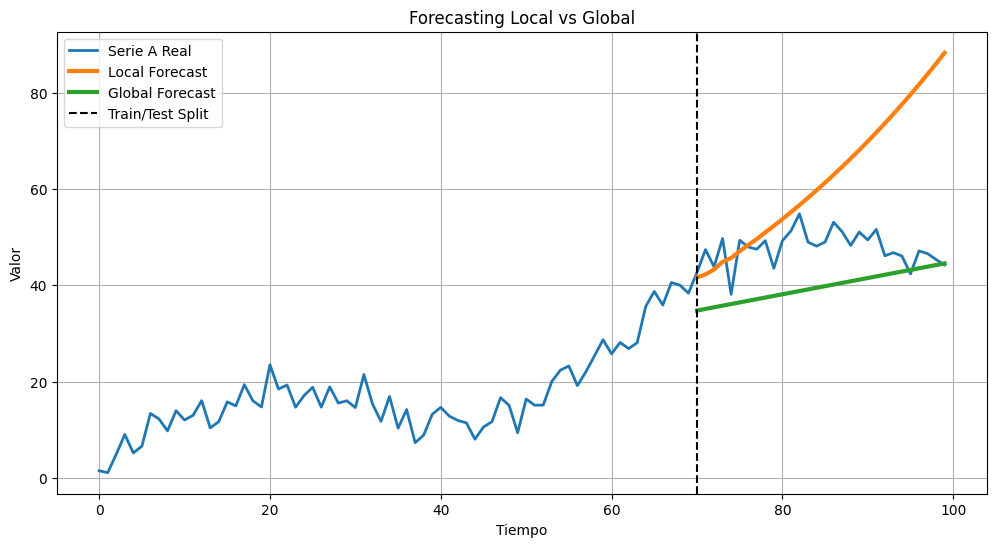

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    t,
    serie_A,
    label="Serie A Real",
    linewidth=2
)


plt.plot(
    t[train_size:],
    pred_local_A,
    label="Local Forecast",
    linewidth=3
)

plt.plot(
    t[train_size:],
    pred_global_A,
    label="Global Forecast",
    linewidth=3
)

plt.axvline(
    train_size,
    linestyle="--",
    color="black",
    label="Train/Test Split"
)

plt.title("Forecasting Local vs Global")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)

plt.show()